<a href="https://colab.research.google.com/github/CokieLee/ProbML-Connections-Project/blob/testing/connections%3F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

constraints of the puzzle space
1. 4 unique groupings of 4 words
2. each word used once
3. 1 solution to the puzzle
4. 16 distinct words
5. categories are not simple (Cultural/Definition/Homophones/Missing letter or added letter/sports/movies) ~ relevence to news/current times "heated" "rivalry"



1. Create words, then group
2. or great groups, then words...

Can try to compute loss by a sum of factors that are weighted

1. group itself
2. misleading group/subgroup exists (for complexity)

Should try to generate words that are relevent to the category, but have multiple meanings (possibly different POS tags)

Similarity between words (through their character embeddings):
- cosine, jaccard

Similarity would be higher in easier level grouping and variance would be lower

"purple category" would most likely by low in similarity

# Option 1: Groups, then words

In [ ]:
!pip -q install nltk wordfreq numpy
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 15.5 MB/s eta 0:00:00


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import json, re, random
from typing import Dict, List, Set, Tuple
from nltk.corpus import wordnet as wn
from wordfreq import zipf_frequency

random.seed(7)

def clean_word(w: str) -> str:
    #remove any odd tokens
    w = w.strip().lower().replace("_", " ")
    w = re.sub(r"\s+", " ", w)
    w = re.sub(r"\s*\([^)]*\)\s*$", "", w).strip()
    return w

def ok_word(w: str, max_tokens: int = 2, min_zipf: float = 3.2) -> bool:
    # min_zipf at 3.2 keeps fairly common words
    #maybe 3.0 if currently too rigid, but more unique words/difficulty up

    if len(w) < 3:
        return False
    if len(w.split()) > max_tokens:
        return False
    if re.search(r"[^a-z\s\-]", w):
        return False
    if zipf_frequency(w, "en") < min_zipf:
        return False
    return True

def expand_hyponyms(root, max_depth: int = 4, limit: int = 500) -> List[str]:
    seen_syn = set()
    words: Set[str] = set()
    stack: List[Tuple] = [(root, 0)]

    while stack and len(words) < limit:
        syn, d = stack.pop()
        if syn.name() in seen_syn:
            continue
        seen_syn.add(syn.name())

        for lemma in syn.lemmas():
            w = clean_word(lemma.name())
            if ok_word(w):
                words.add(w)

        if d < max_depth:
            for h in syn.hyponyms():
                stack.append((h, d + 1))

    return sorted(words)

def title_from_synset(syn) -> str:
    # e.g., "musical_instrument.n.01" -> "Musical instruments"
    lemma = clean_word(syn.lemmas()[0].name())
    # basic pluralization heuristic (good enough for a project)
    if lemma.endswith("y") and not lemma.endswith(("ay","ey","iy","oy","uy")):
        lemma = lemma[:-1] + "ies"
    elif not lemma.endswith("s"):
        lemma = lemma + "s"
    return lemma.title()

def synset_size_proxy(syn, probe_depth: int = 3, probe_cap: int = 120) -> int:
    # fast proxy: expand a bit and count unique acceptable words
    words = expand_hyponyms(syn, max_depth=probe_depth, limit=probe_cap)
    return len(words)

# 1) Scan noun synsets and keep big ones
candidates = []
for syn in wn.all_synsets(pos=wn.NOUN):
    # skip super-generic roots that produce messy categories
    if syn.name() in ("entity.n.01", "object.n.01", "thing.n.01", "whole.n.02"):
        continue
    size = synset_size_proxy(syn, probe_depth=3, probe_cap=160)
    if 50 <= size <= 600:  # tune these
        candidates.append((size, syn))

# sort by size descending, take top slice (avoid too generic)
candidates.sort(reverse=True, key=lambda x: x[0])
print("Candidate synsets:", len(candidates))
print("Top 10 sizes:", [c[0] for c in candidates[:10]])

# 2) make a bank from the top N candidates
N = 300  # how many categories you want to attempt
bank: Dict[str, List[str]] = {}
used_titles = set()

for size, syn in candidates[:N]:
    title = title_from_synset(syn)
    if title in used_titles:
        continue

    words = expand_hyponyms(syn, max_depth=4, limit=800)
    # have categories with enough words
    if len(words) >= 45:
        bank[title] = words
        used_titles.add(title)

print("Final WordNet categories:", len(bank))

with open("category_bank_wordnet.json", "w", encoding="utf-8") as f:
    json.dump(bank, f, ensure_ascii=False, indent=2)

# Peek
sample_keys = random.sample(list(bank.keys()), k=min(15, len(bank)))
for k in sample_keys:
    print(k, "->", bank[k][:12])


Candidate synsets: 547
Top 10 sizes: [165, 163, 162, 162, 162, 162, 162, 161, 161, 161]
Final WordNet categories: 285
Place Of Business -> ['bakery', 'bazaar', 'beauty parlor', 'beauty salon', 'beauty shop', 'betting shop', 'bookstore', 'booth', 'boutique', 'box office', 'business establishment', 'business office']
Messages -> ['a-list', 'abstract', 'absurdity', 'abuse', 'acclaim', 'accommodation', 'accord', 'account', 'accounting', 'accusation', 'acknowledgement', 'ad-lib']
Emotions -> ['aggression', 'alarm', 'anger', 'angst', 'annoyance', 'anxiety', 'awe', 'bad blood', 'bad temper', 'bang', 'bitterness', 'boot']
Social Groups -> ['a-team', 'academy', 'administration', 'administrative body', 'administrative unit', 'affiliate', 'afl', 'agency', 'air crew', 'air force', 'air unit', 'alignment']
Substances -> ['abrasive', 'abrasive material', 'absorption indicator', 'accelerator', 'acid', 'acid dye', 'acid hydrogen', 'acid-base indicator', 'acidic hydrogen', 'acrylic', 'acrylic fiber', '

See here, as a human im scanning and i see 'beauty salon'from places of buisiness and 'care'from improvements

or 'burn' in symptoms and 'band aid' in improvements

how might i select these words over others without checking all pairs of words (that's just infeasible)

In [ ]:
from collections import defaultdict, Counter
import itertools

# bank: dict[str, list[str]]
# Example: bank = json.load(open("category_bank_wordnet.json"))

word_to_cats = defaultdict(list)
for cat, words in bank.items():
    for w in words:
        word_to_cats[w].append(cat)

pair_shared = Counter()
cat_sizes = {cat: len(set(words)) for cat, words in bank.items()}

for w, cats in word_to_cats.items():
    cats = sorted(set(cats))
    if len(cats) < 2:
        continue
    for a, b in itertools.combinations(cats, 2):
        pair_shared[(a, b)] += 1

def jaccard(a, b):
    inter = pair_shared[(a, b)] if (a, b) in pair_shared else pair_shared[(b, a)]
    union = cat_sizes[a] + cat_sizes[b] - inter
    return inter / union if union else 0.0

# Example: get most-overlapping category pairs
top = pair_shared.most_common(30)
top[:5]


[(('Causal Agents', 'Organisms'), 798),
 (('Acts', 'Events'), 600),
 (('Plants', 'Vascular Plants'), 597),
 (('Causal Agents', 'Persons'), 584),
 (('Organisms', 'Persons'), 584)]

#Solver using https://jeremybmerrill.com/blog/2024/08/this-algorithm-solves-nyt-connections.html technique

GloVe word embeddings: measure similarity between words
Incoherence Score: For a group of 4 words compute the average pairwise distance/ distance from each word to the cluster centroid
1. Lower distance = more coherent = more likely to be a real group

Clustering
1. start word
2. find most similar
3. average those two vectors and find 3rd closest vector
4. average those 3 vectors and find the 4th closes
5. candidate cluster made, but now repeat this for all 16 words in the database
6. have a data structure keeping track of the cluster with the lowest incoherence, so like the tightest cluster
7. remove the four words that make the cluster and loop over all of this again until 0 words left (4 clusters made)

In [1]:
pip install gensim numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.4 MB/s eta 0:00:00


In [2]:
import numpy as np
from itertools import combinations
import gensim.downloader as api

print('Loading GloVe (~128MB, takes ~1 min first time)...')
model = api.load('glove-wiki-gigaword-100')
print('Done!')

Loading GloVe (~128MB, takes ~1 min first time)...
[==================================================] 100.0% 128.1/128.1MB downloaded
Done!


In [ ]:
def get_vec(word):
    try:
        return model[word.lower()]
    except KeyError:
        return np.zeros(100)  # unknown word → zero vector

#looks up a word in a pre-trained word embedding model
#(like Word2Vec or GloVe, stored in model)
#Each word becomes a vector of 100 numbers representing its meaning
#Unknown words get a zero vector

def incoherence(words):
    vecs = np.array([get_vec(w) for w in words])
    centroid = vecs.mean(axis=0) #average of the group
    return np.linalg.norm(vecs - centroid, axis=1).mean()
#returns mean distance of each word from that center
#low score = tight, coherent group
#high score = loose, unrelated words

def build_cluster(seed, pool):
    cluster = [seed]
    remaining = [w for w in pool if w != seed]
    for _ in range(3):
        centroid = np.mean([get_vec(w) for w in cluster], axis=0)
        best = min(remaining, key=lambda w: np.linalg.norm(get_vec(w) - centroid))
        cluster.append(best)
        remaining.remove(best)
    return cluster
#greedily builds a group of 4 starting from a seed word
#At each step, it picks whichever remaining word is closest to the current group's centroid
#nearest-neighbor approach

def solve_greedy(words):
    remaining = list(words)
    solution = []
    while len(remaining) >= 4:
        best, best_score = None, float('inf')
        for seed in remaining:
          c = build_cluster(seed, remaining)
          s = incoherence(c)
          if s < best_score:
            best_score, best = s, c
        solution.append((best, round(best_score, 4)))

        for w in best:
            remaining.remove(w)
    return solution
#try every possible seed word and keep the tightest cluster
#then remove those 4 words and repeat
#never looks back so once found, done

def solve_exhaustive(words, top_n=5):
    results = []
    for first in combinations(words, 4):
        rest = [w for w in words if w not in first]
        tail = solve_greedy(rest)
        total = incoherence(list(first)) + sum(s for _, s in tail)
        full = [(list(first), round(incoherence(list(first)), 4))] + tail
        results.append((full, round(total, 4)))
    results.sort(key=lambda x: x[1])
    return results[:top_n]

#tries every possible combination of 4 words as the first group
#then uses solve_greedy for the remaining 12
#ranks all attempts by total incoherence score
# returns the top n solutions
#more thorough but much slower
#1,820 possible first groups from 16 words
#brute-force the first group, greedy for the rest

def print_solution(solution, title='Solution'):
    colors = ['Yellow', 'Green', 'Blue', 'Purple']
    for i, (group, score) in enumerate(solution):
        label = colors[i] if i < len(colors) else f'Group {i+1}'
        print(f'{label:25s} Δ={score:.4f}:    {", ".join(w.upper() for w in group)}')
    total = sum(s for _, s in solution)
    print(f'{"":25s} total={total:.4f}\n')

In [ ]:
words = [
    'handful', 'several', 'post',    'planet',
    'moon',    'mellon',  'comet',   'pair',
    'asteroid','plumb',   'sun',     'some',
    'journal', 'few',     'lyme',    'globe',
]

solution = solve_greedy(words)
print_solution(solution, 'Greedy')

Yellow                    Δ=2.0076:    HANDFUL, FEW, SEVERAL, SOME
Green                     Δ=3.4756:    COMET, ASTEROID, PLANET, MOON
Blue                      Δ=3.5726:    POST, GLOBE, JOURNAL, PAIR
Purple                    Δ=4.5959:    PLUMB, LYME, MELLON, SUN
                          total=13.6517



In [ ]:
top5 = solve_exhaustive(words, top_n=5)

for rank, (sol, total) in enumerate(top5):
    print_solution(sol, f'Rank {rank+1}  (total Δ={total})')

Yellow                    Δ=3.6335:    POST, SUN, JOURNAL, GLOBE
Green                     Δ=2.0076:    HANDFUL, FEW, SEVERAL, SOME
Blue                      Δ=3.4756:    PLANET, MOON, COMET, ASTEROID
Purple                    Δ=4.3373:    PAIR, PLUMB, LYME, MELLON
                          total=13.4540

Yellow                    Δ=4.3373:    MELLON, PAIR, PLUMB, LYME
Green                     Δ=2.0076:    HANDFUL, FEW, SEVERAL, SOME
Blue                      Δ=3.4756:    COMET, ASTEROID, PLANET, MOON
Purple                    Δ=3.6335:    SUN, POST, GLOBE, JOURNAL
                          total=13.4540

Yellow                    Δ=3.6451:    POST, PAIR, SUN, GLOBE
Green                     Δ=2.0076:    HANDFUL, FEW, SEVERAL, SOME
Blue                      Δ=3.4756:    PLANET, MOON, COMET, ASTEROID
Purple                    Δ=4.4779:    PLUMB, LYME, MELLON, JOURNAL
                          total=13.6062

Yellow                    Δ=4.4779:    MELLON, PLUMB, JOURNAL, LYME
Green      

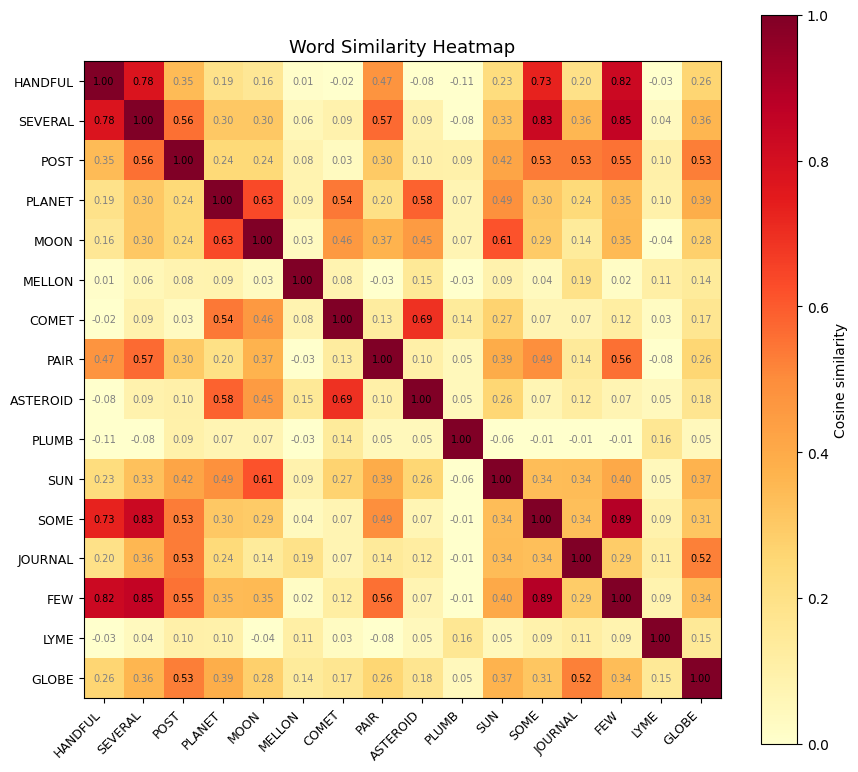

In [ ]:
import matplotlib.pyplot as plt

def plot_heatmap(words):
    N = len(words)
    mat = np.zeros((N, N))
    for i, w1 in enumerate(words):
        v1 = get_vec(w1)
        for j, w2 in enumerate(words):
            v2 = get_vec(w2)
            norm = np.linalg.norm(v1) * np.linalg.norm(v2)
            mat[i, j] = np.dot(v1, v2) / norm if norm > 0 else 0

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(mat, cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_xticks(range(N)); ax.set_xticklabels([w.upper() for w in words], rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(N)); ax.set_yticklabels([w.upper() for w in words], fontsize=9)
    for i in range(N):
        for j in range(N):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if mat[i,j] > 0.5 else 'gray')
    plt.colorbar(im, ax=ax, label='Cosine similarity')
    ax.set_title('Word Similarity Heatmap', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_heatmap(words)

In [ ]:
my_words = [
    'grasshopper',  'shamrock',  'statue of liberty',  'wasabi',
    'crossroads',  'landmark',  'milestone',  'watershed',
    'callback',  'punchline', 'setup', 'timing',
    'pretty', 'attention', 'check', 'drumroll',]

solution = solve_greedy(my_words)
print_solution(solution, 'My Puzzle — Greedy')

Yellow                    Δ=2.7112:    STATUE OF LIBERTY, PUNCHLINE, CALLBACK, DRUMROLL
Green                     Δ=3.2640:    SETUP, TIMING, CHECK, ATTENTION
Blue                      Δ=3.2963:    CROSSROADS, MILESTONE, LANDMARK, WATERSHED
Purple                    Δ=4.1072:    GRASSHOPPER, SHAMROCK, WASABI, PRETTY
                          total=13.3787



In [ ]:
top5 = solve_exhaustive(my_words, top_n=5)

for rank, (sol, total) in enumerate(top5):
    print_solution(sol, f'Rank {rank+1}  (total Δ={total})')

Yellow                    Δ=3.2564:    GRASSHOPPER, SHAMROCK, STATUE OF LIBERTY, WASABI
Green                     Δ=3.1581:    CALLBACK, PUNCHLINE, DRUMROLL, SETUP
Blue                      Δ=3.2963:    CROSSROADS, MILESTONE, LANDMARK, WATERSHED
Purple                    Δ=3.3132:    TIMING, ATTENTION, CHECK, PRETTY
                          total=13.0240

Yellow                    Δ=3.6790:    GRASSHOPPER, SHAMROCK, WASABI, CALLBACK
Green                     Δ=2.7924:    STATUE OF LIBERTY, PUNCHLINE, DRUMROLL, SETUP
Blue                      Δ=3.2963:    CROSSROADS, MILESTONE, LANDMARK, WATERSHED
Purple                    Δ=3.3132:    TIMING, ATTENTION, CHECK, PRETTY
                          total=13.0809

Yellow                    Δ=2.7924:    STATUE OF LIBERTY, PUNCHLINE, SETUP, DRUMROLL
Green                     Δ=3.2963:    CROSSROADS, MILESTONE, LANDMARK, WATERSHED
Blue                      Δ=3.3132:    TIMING, ATTENTION, CHECK, PRETTY
Purple                    Δ=3.6790:    WASA

i think a more resonable solution that would actually work would be that after selecting the categories for green and yellow, which are the lowest, so like after removing those 8, then the similarity isn't ranked based on just high to low but actually an average~